In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../01_Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 7043
Number of Columns: 21


In [6]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [7]:
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [8]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
# Check data types
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [12]:
# Convert TotalCharges into numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values after conversion
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

Missing values in TotalCharges: 11


In [13]:
# Check customers with missing TotalCharges

df[df['TotalCharges'].isnull()][
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
]

Task was destroyed but it is pending!
task: <Task pending name='Task-92' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Ankit Jangir\miniconda3\envs\datascience\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-93' coro=<Kernel.shell_main() running at C:\Users\Ankit Jangir\miniconda3\envs\datascience\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Ankit Jangir\miniconda3\envs\datascience\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\Ankit Jangir\miniconda3\envs\datascience\Lib\site-packages\pandas\core\array_algos\take.py:265: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def _get_take_nd_function(
Task was destroyed but it is pending!
task: <Task pending name='Task-93' coro=<Kernel.shell_main() running at C:\Users\Ankit Jangir\miniconda3\envs\datascience\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [14]:
# Remove records with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])

# Reset index
df = df.reset_index(drop=True)

# Check result
print("Dataset Shape After Cleaning:", df.shape)
print("Missing TotalCharges:", df['TotalCharges'].isnull().sum())

Dataset Shape After Cleaning: (7032, 21)
Missing TotalCharges: 0


In [15]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [16]:
# Check unique values in categorical columns

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


customerID:
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7032, dtype: str

gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<StringArray>
['No', 'Yes', 'No internet 

C:\Users\Ankit Jangir\AppData\Local\Temp\ipykernel_16232\2272029680.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [17]:
# Check for leading/trailing spaces in categorical columns

for col in categorical_columns:
    space_count = (df[col] != df[col].str.strip()).sum()
    print(f"{col}: {space_count} values with extra spaces")

customerID: 0 values with extra spaces
gender: 0 values with extra spaces
Partner: 0 values with extra spaces
Dependents: 0 values with extra spaces
PhoneService: 0 values with extra spaces
MultipleLines: 0 values with extra spaces
InternetService: 0 values with extra spaces
OnlineSecurity: 0 values with extra spaces
OnlineBackup: 0 values with extra spaces
DeviceProtection: 0 values with extra spaces
TechSupport: 0 values with extra spaces
StreamingTV: 0 values with extra spaces
StreamingMovies: 0 values with extra spaces
Contract: 0 values with extra spaces
PaperlessBilling: 0 values with extra spaces
PaymentMethod: 0 values with extra spaces
Churn: 0 values with extra spaces


In [18]:
# Final Data Quality Check

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (7032, 21)

Missing Values:
0

Duplicate Rows:
0

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [19]:
# Save cleaned dataset

cleaned_path = "../01_Dataset/Customer_Churn_Cleaned.csv"

df.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved successfully!")
print("File:", cleaned_path)

Cleaned dataset saved successfully!
File: ../01_Dataset/Customer_Churn_Cleaned.csv


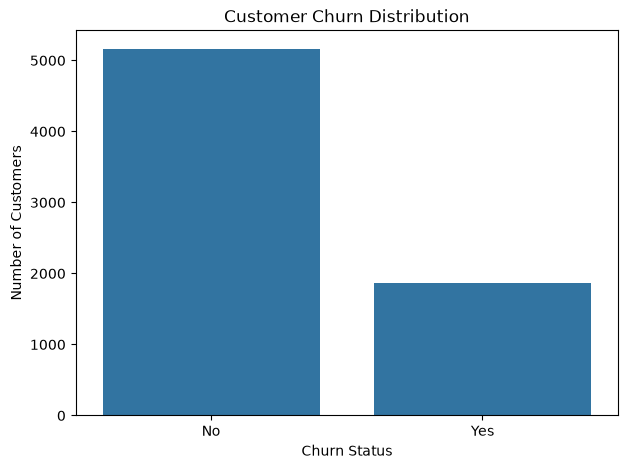

In [20]:
# Churn Distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

plt.show()

In [21]:
# Churn Percentage

churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print("Churn Percentage:")
print(churn_percentage.round(2))

Churn Percentage:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


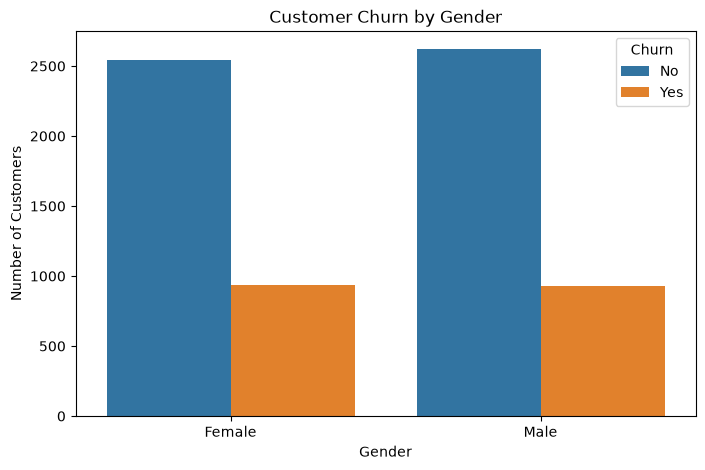

In [22]:
# Churn by Gender

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='gender', hue='Churn')

plt.title('Customer Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

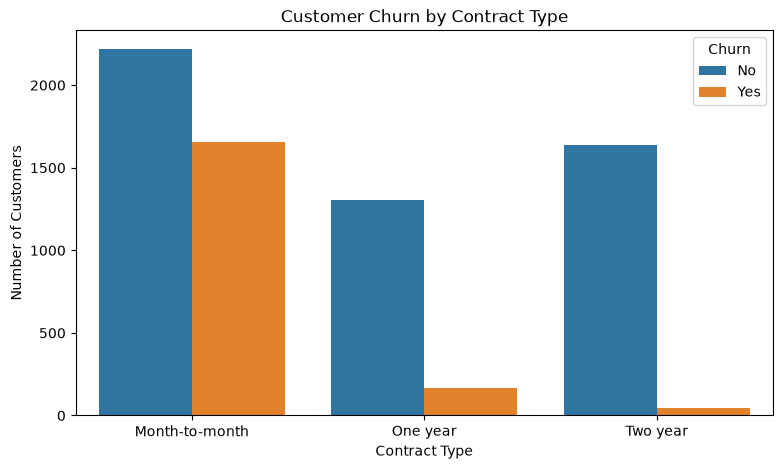

In [23]:
# Churn by Contract Type

plt.figure(figsize=(9, 5))

sns.countplot(data=df, x='Contract', hue='Churn')

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.show()

In [24]:
# Churn Rate by Contract Type

contract_churn_rate = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print("Churn Rate by Contract Type (%):")
print(contract_churn_rate.round(2))

Churn Rate by Contract Type (%):
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85


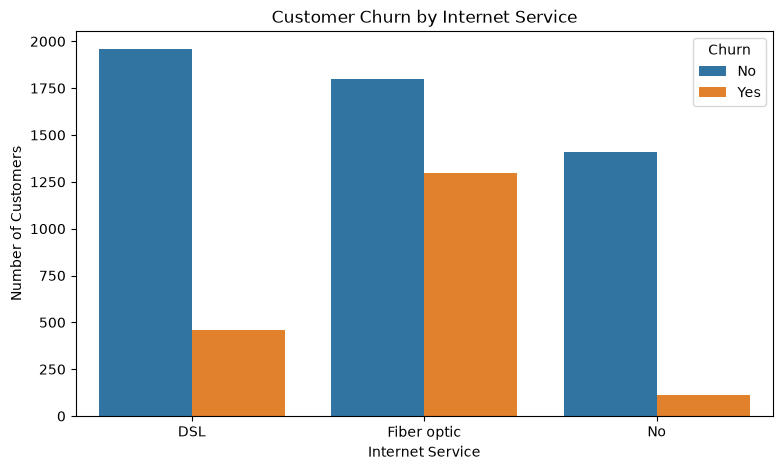

In [25]:
# Churn by Internet Service

plt.figure(figsize=(9, 5))

sns.countplot(data=df, x='InternetService', hue='Churn')

plt.title('Customer Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

In [26]:
# Churn Rate by Internet Service

internet_churn_rate = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

print("Churn Rate by Internet Service (%):")
print(internet_churn_rate.round(2))

Churn Rate by Internet Service (%):
Churn               No    Yes
InternetService              
DSL              81.00  19.00
Fiber optic      58.11  41.89
No               92.57   7.43


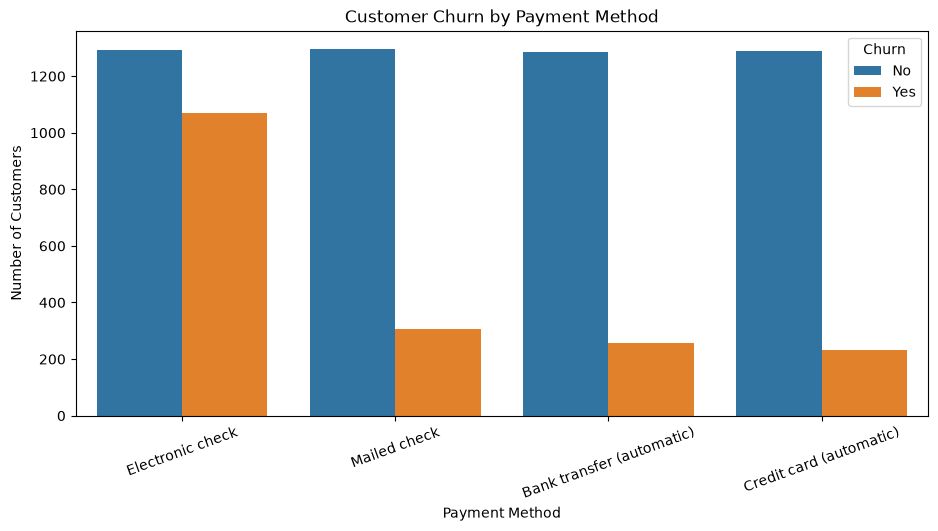

In [27]:
# Churn by Payment Method

plt.figure(figsize=(11, 5))

sns.countplot(data=df, x='PaymentMethod', hue='Churn')

plt.title('Customer Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)

plt.show()

In [28]:
# Churn Rate by Payment Method

payment_churn_rate = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

print("Churn Rate by Payment Method (%):")
print(payment_churn_rate.round(2))

Churn Rate by Payment Method (%):
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.27  16.73
Credit card (automatic)    84.75  15.25
Electronic check           54.71  45.29
Mailed check               80.80  19.20


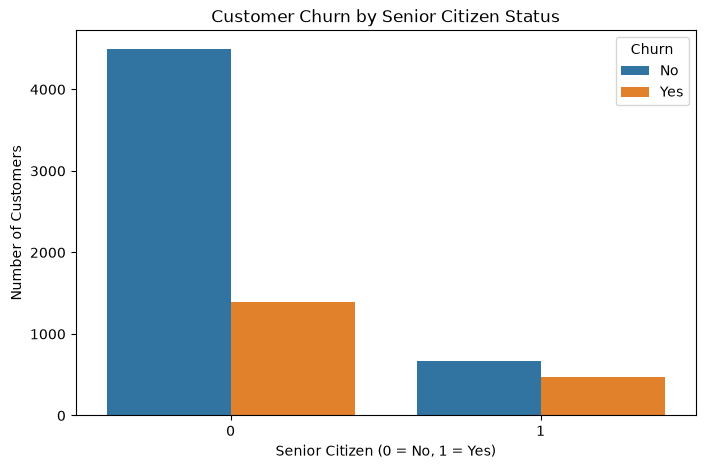

In [29]:
# Churn by Senior Citizen

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='SeniorCitizen', hue='Churn')

plt.title('Customer Churn by Senior Citizen Status')
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')

plt.show()

In [30]:
# Churn Rate by Senior Citizen Status

senior_churn_rate = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

print("Churn Rate by Senior Citizen Status (%):")
print(senior_churn_rate.round(2))

Churn Rate by Senior Citizen Status (%):
Churn             No    Yes
SeniorCitizen              
0              76.35  23.65
1              58.32  41.68


In [31]:
# Create Tenure Groups

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 Months', '13-24 Months', '25-48 Months', '49-72 Months'],
    include_lowest=True
)

print(df['TenureGroup'].value_counts().sort_index())

TenureGroup
0-12 Months     2175
13-24 Months    1024
25-48 Months    1594
49-72 Months    2239
Name: count, dtype: int64


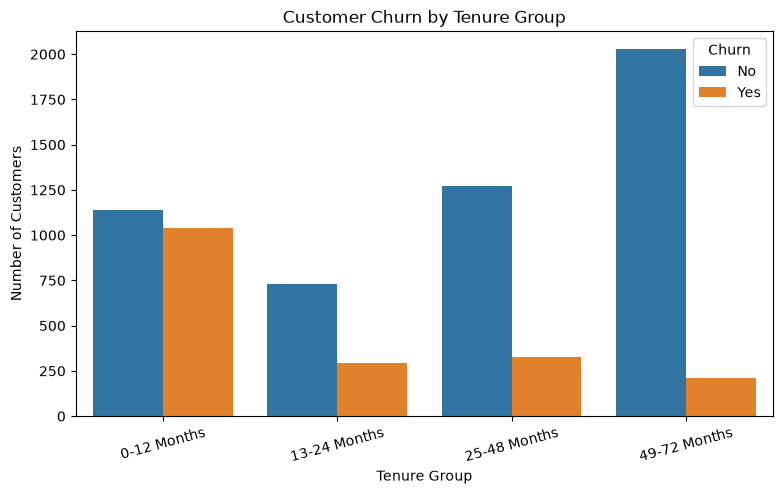

In [32]:
# Customer Churn by Tenure Group

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='TenureGroup',
    hue='Churn'
)

plt.title('Customer Churn by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)

plt.show()

In [33]:
# Churn Rate by Tenure Group

tenure_churn_rate = pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
) * 100

print("Churn Rate by Tenure Group (%):")
print(tenure_churn_rate.round(2))

Churn Rate by Tenure Group (%):
Churn            No    Yes
TenureGroup               
0-12 Months   52.32  47.68
13-24 Months  71.29  28.71
25-48 Months  79.61  20.39
49-72 Months  90.49   9.51


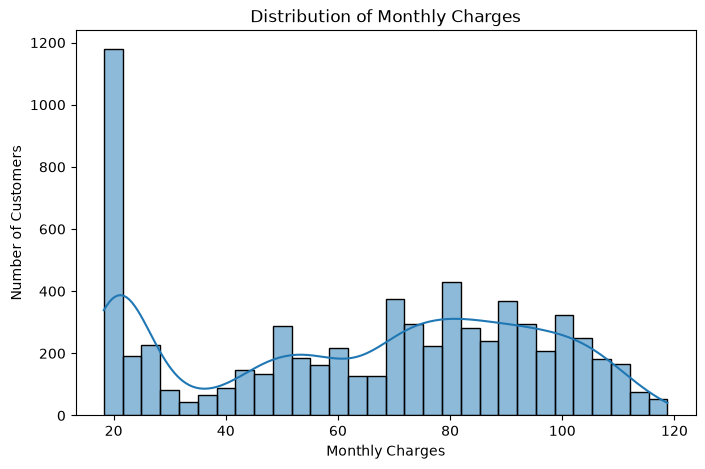

In [34]:
# Monthly Charges Distribution

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='MonthlyCharges', bins=30, kde=True)

plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')

plt.show()

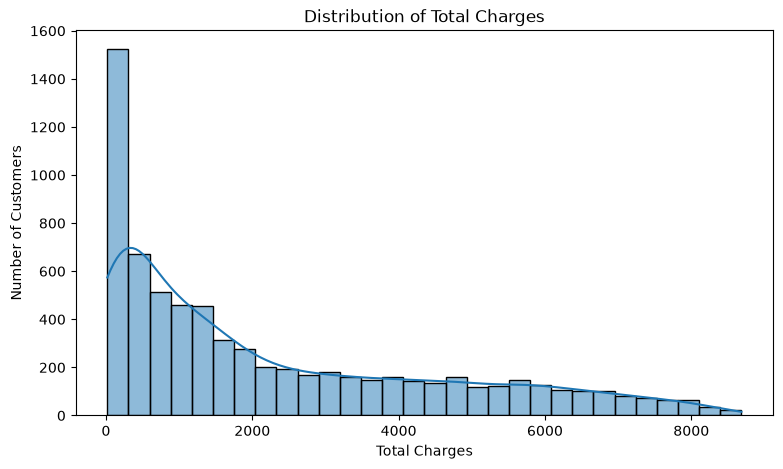

In [35]:
# Distribution of Total Charges

plt.figure(figsize=(9, 5))

sns.histplot(df['TotalCharges'], bins=30, kde=True)

plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')

plt.show()

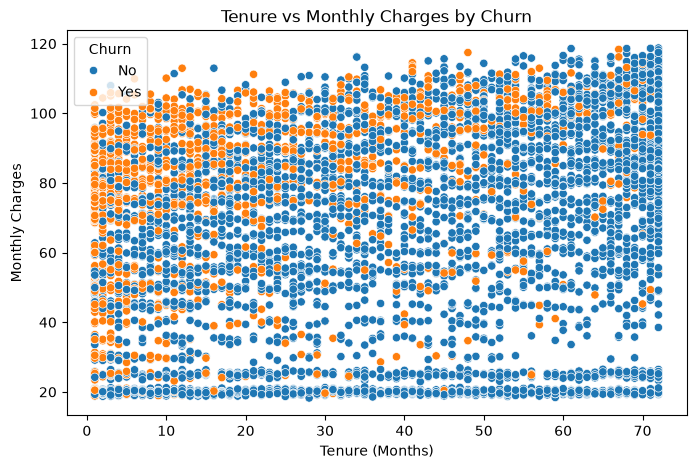

In [36]:
# Tenure vs Monthly Charges

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn'
)

plt.title('Tenure vs Monthly Charges by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges')
plt.show()

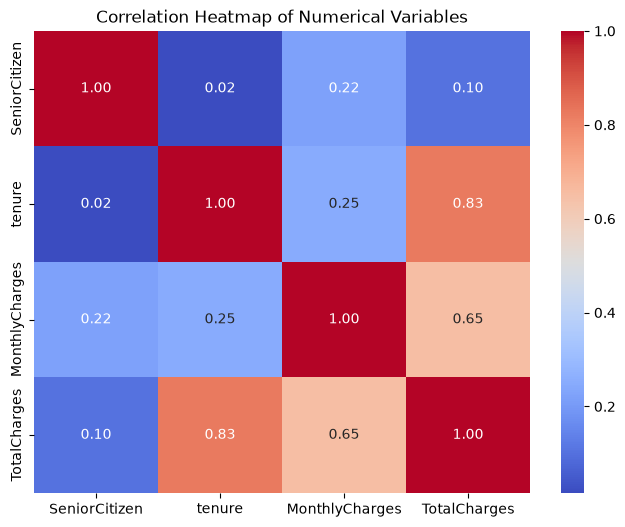

In [37]:
# Correlation Heatmap

plt.figure(figsize=(8, 6))

correlation = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

# 5. Basic Statistical Analysis

Basic statistical analysis is performed to understand the central tendency,
dispersion, and relationships among numerical variables in the customer churn dataset.

The main statistical measures include:
- Mean
- Median
- Standard Deviation
- Variance
- Minimum and Maximum
- Correlation Analysis

In [38]:
# Descriptive Statistics

numeric_columns = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

print("Descriptive Statistics:")
print(df[numeric_columns].describe().round(2))

Descriptive Statistics:
       SeniorCitizen   tenure  MonthlyCharges  TotalCharges
count        7032.00  7032.00         7032.00       7032.00
mean            0.16    32.42           64.80       2283.30
std             0.37    24.55           30.09       2266.77
min             0.00     1.00           18.25         18.80
25%             0.00     9.00           35.59        401.45
50%             0.00    29.00           70.35       1397.48
75%             0.00    55.00           89.86       3794.74
max             1.00    72.00          118.75       8684.80


##  Central Tendency and Dispersion

In this section, we calculate important statistical measures such as Mean, Median, Standard Deviation, and Variance to understand the distribution and variability of numerical customer attributes.

In [39]:
# Mean, Median, Standard Deviation and Variance

stats_summary = pd.DataFrame({
    'Mean': df[numeric_columns].mean(),
    'Median': df[numeric_columns].median(),
    'Standard Deviation': df[numeric_columns].std(),
    'Variance': df[numeric_columns].var()
})

print("Central Tendency and Dispersion:")
print(stats_summary.round(2))

Central Tendency and Dispersion:
                   Mean   Median  Standard Deviation    Variance
SeniorCitizen      0.16     0.00                0.37        0.14
tenure            32.42    29.00               24.55      602.47
MonthlyCharges    64.80    70.35               30.09      905.17
TotalCharges    2283.30  1397.48             2266.77  5138252.41


In [40]:
# Minimum and Maximum Values

min_max = pd.DataFrame({
    'Minimum': df[numeric_columns].min(),
    'Maximum': df[numeric_columns].max()
})

print("Minimum and Maximum Values:")
print(min_max.round(2))

Minimum and Maximum Values:
                Minimum  Maximum
SeniorCitizen      0.00     1.00
tenure             1.00    72.00
MonthlyCharges    18.25   118.75
TotalCharges      18.80  8684.80


## Statistical Insights

The statistical analysis helps understand the central tendency, variability, and relationships among important numerical customer attributes such as tenure, monthly charges, total charges, and senior citizen status.

Key statistical measures including mean, median, standard deviation, variance, minimum, maximum, and correlation were analyzed to identify important patterns in the customer dataset.

# Business Insights from EDA and Statistical Analysis

Based on the exploratory data analysis and statistical analysis, the following key business insights were identified:

1. Customer churn is relatively higher among customers with shorter tenure.

2. Customers in the 0–12 months tenure group show the highest churn proportion, indicating higher early-stage customer risk.

3. Long-tenure customers generally show lower churn rates, suggesting stronger customer retention over time.

4. Monthly Charges show noticeable variation across customers, with higher charges potentially associated with different customer service combinations.

5. Total Charges are strongly related to customer tenure because customers who stay longer generally accumulate higher total charges.

6. Tenure and Total Charges show a strong positive relationship.

7. Monthly Charges and Total Charges also show a positive relationship.

8. The analysis indicates that customer tenure, contract-related factors, and charging patterns are important variables for understanding customer retention.